# Object-Oriented Programming for Machine Learning

In the previous notebook, we used classes to represent objects such as animals and zoos.

In this notebook, we use the same idea for a small machine learning system.

Our goal is not to build a full deep learning library.

Our goal is to understand how object-oriented programming helps us make code more modular.

We will build three kinds of objects:

- **Models**: objects that make predictions and compute gradients.
- **Parameters**: objects that store values and gradients.
- **Optimizers**: objects that update parameters.

At the end, we will have a PyTorch-like training loop:

```python
optimizer.zero_grad()
model.backward(x, y)
optimizer.step()

The important idea is:

The model should not know how Adam works.

Adam should not know the formula of linear regression.

They only need to agree on a small interface.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## 1. A very small dataset

We start with a synthetic linear regression dataset.

The true relation is approximately:

$y = 3x + 2$

with some random noise added.

This is useful because we know what the model should learn:

- the weight should become close to `3`
- the bias should become close to `2`

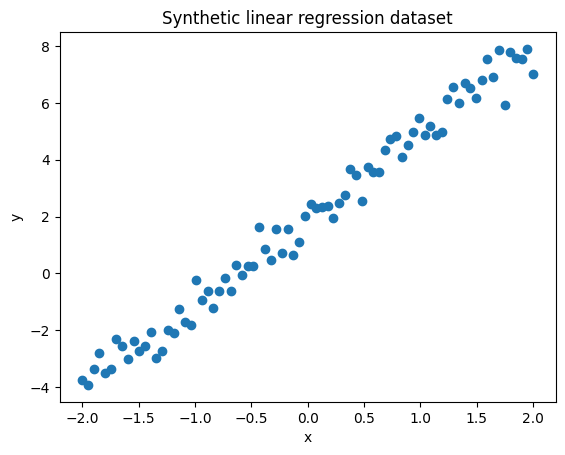

In [2]:
n = 80

x = np.linspace(-2, 2, n)
noise = np.random.normal(0, 0.5, size=n)

y = 3 * x + 2 + noise

plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic linear regression dataset")
plt.show()

## 2. First version: model + optimizer, without `Parameter`

Let us start simple.

We create a `LinearRegressionV1` class.

The model has two attributes:

- `w`: the weight
- `b`: the bias

The model also has methods:

- `predict(x)`: computes predictions
- `gradients(x, y)`: computes gradients of the mean squared error and return the gradients

Given that $\hat{y}_i = w \cdot x_i + b$, the formula for MSE is:$$MSE = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2$$

1. Gradient with respect to $w$:
$$\frac{\partial MSE}{\partial w} = \frac{2}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i) \cdot x_i$$

2. Gradient with respect to $b$:
$$\frac{\partial MSE}{\partial b} = \frac{2}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)$$

**Hint**: in python if given vector $a$ and vector $b$, $a-b$ gives the entriwise difference vector

In [ ]:
class LinearRegressionV1:
    def __init__(self, w=0.0, b=0.0):
        self.w = w
        self.b = b

    # 🎯🎯🎯 TODO #1 🎯🎯🎯: Implement the predict function that
    #                        returns the prediction y_hat = w*x + b
    def predict(self, x):
        return self.w * x + self.b



    def gradients(self, x, y):
    #🎯🎯🎯 TODO #2 🎯🎯🎯: The prediction using the method that you
    #                       have just implemented
        y_pred = self.predict(x)
        error = y_pred - y

    # 🎯🎯🎯 TODO #3 🎯🎯🎯: compute the gradients of MSE with respect to w and b
    # MSE = mean((y_pred - y)^2)
        N = len(x)
        dw = (2 / N) * np.sum(error * x)
        db = (2 / N) * np.sum(error)


    # 🎯🎯🎯 TODO #4 🎯🎯🎯: returning the gradients


In [ ]:
# Quick checks

model = LinearRegressionV1(w=2.0, b=1.0)

assert np.allclose(model.predict(np.array([1.0, 2.0])), np.array([3.0, 5.0]))

dw, db = model.gradients(x, y)
assert isinstance(dw, float) or np.isscalar(dw)
assert isinstance(db, float) or np.isscalar(db)

print("Looks good!")

## 3. First Optimizer: Manual Gradient Descent

Now it's time to create our optimizer. If the model makes predictions and the loss calculates the error, the optimizer is the engine that actually drives the learning.

Its sole responsibility is to take the "error signals" (gradients) and update the model's parameters to make better predictions next time.

In this initial version, our `step` function receives:
* The `model` being trained
* The computed `grads` (gradients for $w$ and $b$)

**A quick note on design:** You'll notice this setup isn't perfectly modular. The optimizer explicitly assumes our model has specific attributes named `w` and `b`. While modern frameworks (like PyTorch or TensorFlow) abstract this away so optimizers can update *any* model architecture automatically, hardcoding it here is the best way to see exactly how the gears turn under the hood.

**Your Task:**
We are going to implement plain gradient descent. To minimize our error, we need to update our weights by stepping in the *opposite* direction of the gradient. The size of this step is controlled by the learning rate ($\eta$, which is stored as `self.lr` in our class).

Translate the following mathematical update rules into your code:

$$w \leftarrow w - \eta \cdot dw$$
$$b \leftarrow b - \eta \cdot db$$

In [ ]:
class GradientDescentManual:
    def __init__(self, lr=0.01):
        self.lr = lr

    def step(self, model, grads): #grads will the the tuple containing the gradients
    #of w and b
        dw, db = grads   # we separate the gradients

        # 🎯🎯🎯 TODO #5 🎯🎯🎯:
        # update model's parameters using the gradients

In [ ]:
model = LinearRegressionV1(w=1.0, b=1.0)
optimizer = GradientDescentManual(lr=0.1)

optimizer.step(model, grads=(2.0, 3.0))

assert np.isclose(model.w, 0.8)
assert np.isclose(model.b, 0.7)

print("Looks good!")

## 4. Training loop

Now we train the model.

This is still a simplified training loop.

The model computes the gradients, and the optimizer updates the model.

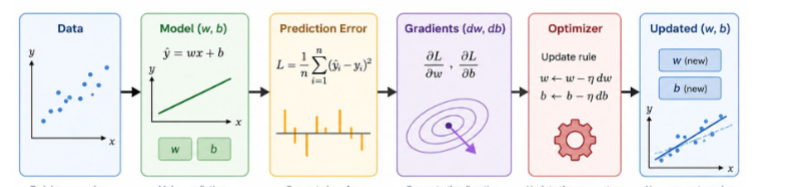

In [ ]:
def mse(y_pred, y):
    return np.mean((y_pred - y) ** 2)

#Implementing the training pipeline shown in the picture
    #using the classes designed above
def train_v1(model, optimizer, x, y, epochs=100):
    losses = []


    for epoch in range(epochs):
      # making the prediction
        y_pred = model.predict(x)
        loss = mse(y_pred, y) #appending loss is done for later plotting
        losses.append(loss)
      # 🎯🎯🎯 TODO #6 🎯🎯🎯: asking the model for gradients

      #🎯🎯🎯 TODO #7 🎯🎯🎯: updating model's parameters using the step function


    return losses

In [ ]:
model = LinearRegressionV1(w=0.0, b=0.0)
optimizer = GradientDescentManual(lr=0.05)

losses = train_v1(model, optimizer, x, y, epochs=100)

print("Learned w:", model.w)
print("Learned b:", model.b)
print("Final loss:", losses[-1])

In [ ]:
plt.scatter(x, y, label="data")
plt.plot(x, model.predict(x), label="model")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear regression after training")
plt.legend()
plt.show()

plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training loss")
plt.show()

## 5. Why Our Current Setup Needs an Upgrade

Our previous version works perfectly for our simple model, which is a great start!

However, there is a hidden problem: right now, our optimizer specifically looks for `model.w` and `model.b` to do its job. This means the optimizer is essentially "snooping" into the model's internal details.

**Why is this a problem?**
Imagine what happens when we want to build something bigger. What if we build a neural network with hundreds or thousands of differently named parameters? Our current optimizer would immediately break because it wouldn't be able to find `w` and `b`.

In good code design (often called making things "modular"), different parts of your code should act like Lego bricks. They should click together easily without needing to know everything about each other.

A good optimizer shouldn't care if the numbers it is updating belong to:
* A simple linear regression model
* A massive, complex neural network
* Something else entirely

Think of the optimizer like a specialized worker on an assembly line with a wrench:

> "Just hand me the bolts (parameters) and tell me how much to turn them (gradients). I will tighten them for you. I don't need to know if I'm helping build a bicycle or a rocket ship."

To fix this and make our code truly flexible, we need a standard way to hand those "bolts" to the optimizer. To do this, we are going to introduce a new class: `Parameter`.

## 6. Introducing the `Parameter` class

A parameter stores two things:

- `value`: the current value of the parameter
- `grad`: the gradient of the loss with respect to that value

This is inspired by PyTorch.

In real PyTorch, a `Parameter` is a special kind of tensor.

Here we use a much simpler version.

In [ ]:
class Parameter:
    def __init__(self, value):
        # 🎯🎯🎯 TODO #8 🎯🎯🎯: store the value
        self.value = ...

        # 🎯🎯🎯 TODO #9 🎯🎯🎯: initialize the gradient with zeros of the same shape
        # Hint: there is a specific numpy function that creates a 0 array
        # of the same shape of the element
        self.grad = ...

In [ ]:
p1 = Parameter(3.0)
assert p1.value == 3.0
assert p1.grad == 0.0

p2 = Parameter(np.array([1.0, 2.0]))
assert np.allclose(p2.value, np.array([1.0, 2.0]))
assert np.allclose(p2.grad, np.array([0.0, 0.0]))

print("Looks good!")

## 7. A base class for models

Now we introduce a simple base class called `Module`.

This is inspired by `torch.nn.Module`.

A `Module` defines the interface that our models should follow.

Every model in this notebook should provide:

- `parameters()`: returns the list of parameters
- `predict(x)`: computes predictions
- `backward(x, y)`: computes gradients and writes them into the parameters

This is important because we want the same training loop to work for different models.

For example, both `LinearRegression` and `SimpleNeuralNetwork` will inherit from `Module`.

They will have different internal formulas, but they will expose the same interface.

In [ ]:
class Module:
    def parameters(self):
        raise NotImplementedError

    def predict(self, x):
        raise NotImplementedError

    def backward(self, x, y):
        raise NotImplementedError

## 8. Linear regression with `Parameter`

Now the linear regression model contains two `Parameter` objects:

- `self.w`
- `self.b`

This changes the workflow.

In the first version, the model returned the gradients:

    dw, db = model.gradients(x, y)

Now the model writes the gradients directly into the parameters:

    self.w.grad += dw
    self.b.grad += db

So `backward()` does not need to return anything.

The model is still responsible for computing gradients, because the model knows its own formula.

The optimizer is responsible only for updating parameters.

This is the key separation of responsibilities:

- the model computes gradients
- the parameters store values and gradients
- the optimizer updates parameter values

In [ ]:
class LinearRegression(Module):
    def __init__(self):
        self.w = Parameter(0.0)
        self.b = Parameter(0.0)

    def parameters(self):
        return [self.w, self.b]

    def predict(self, x):
        return self.w.value * x + self.b.value

    def backward(self, x, y):
        y_pred = self.predict(x)
        error = y_pred - y

        dw = 2 * np.mean(error * x)
        db = 2 * np.mean(error)

        # We accumulate gradients, PyTorch-style.
        self.w.grad += dw
        self.b.grad += db

In [ ]:
model = LinearRegression()

assert len(model.parameters()) == 2
assert isinstance(model.w, Parameter)
assert isinstance(model.b, Parameter)

model.backward(x, y)

assert model.w.grad != 0.0
assert model.b.grad != 0.0

print("Looks good!")

## 9. A base class for optimizers

Now we create an `Optimizer` base class.

An optimizer receives a list of parameters.

It does not know anything about the model.

It only knows that each parameter has:

- `.value`
- `.grad`

This is why the `Parameter` class makes the design cleaner.

Before, the optimizer had to know about `model.w` and `model.b`.

Now, the optimizer only loops over parameters:

    for p in self.params:
        update p.value using p.grad

This means the same optimizer can work with linear regression, neural networks, or other models.

In [ ]:
class Optimizer:
    def __init__(self, params, lr):
        self.params = list(params)
        self.lr = lr

    def zero_grad(self):
        # In our design, backward() accumulates gradients using +=.
        # Therefore, before computing new gradients, we reset old ones.
        for p in self.params:
            p.grad = np.zeros_like(p.grad)

    def step(self):
        raise NotImplementedError

## 10. What changed in the workflow?

Before introducing `Parameter`, the model returned the gradients.

The workflow was:

    grads = model.gradients(x, y)
    optimizer.step(model, grads)

This works, but the optimizer is still strongly connected to the specific model.

Why?

Because the optimizer needs the model in order to modify its attributes:

    model.w
    model.b

So the optimizer needs to know that this specific model has parameters called `w` and `b`.

After introducing `Parameter`, the workflow changes.

Now the model's `backward()` method does not return gradients.

Instead, it writes the gradients directly inside the parameter objects:

    self.w.grad += dw
    self.b.grad += db

The optimizer receives the parameter objects when it is created:

    optimizer = GradientDescent(model.parameters(), lr=0.05)

This means that the optimizer already has access to the same parameter objects stored inside the model.

**The model owns the parameters, and the optimizer receives references to the same parameter objects!!!!**

So `optimizer.step()` does not need the model anymore.

It only does:

    for p in self.params:
        p.value = p.value - lr * p.grad

This is the key idea:

> The model computes gradients.  
> The parameters store values and gradients.  
> The optimizer updates parameters.

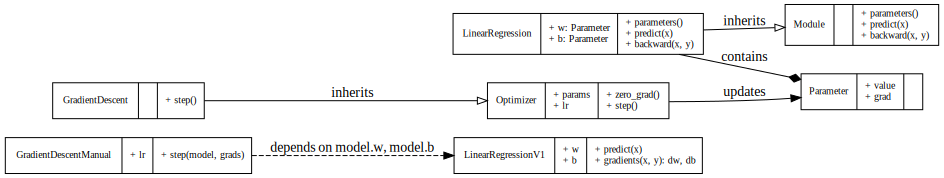

In [ ]:
# @title 📐 OOP Design — UML class diagram (run to render) { display-mode: "form" }
from graphviz import Digraph
from IPython.display import display

uml = Digraph("oop_design", format="png")
uml.attr(rankdir="LR")
uml.attr("node", shape="record", fontsize="10")

# -------------------------
# Before
# -------------------------
uml.node(
    "LinearRegressionV1",
    "{LinearRegressionV1|+ w\\l+ b\\l|+ predict(x)\\l+ gradients(x, y): dw, db\\l}"
)

uml.node(
    "GradientDescentManual",
    "{GradientDescentManual|+ lr\\l|+ step(model, grads)\\l}"
)

uml.edge(
    "GradientDescentManual",
    "LinearRegressionV1",
    label="depends on model.w, model.b",
    style="dashed"
)

# -------------------------
# After
# -------------------------
uml.node(
    "Module",
    "{Module||+ parameters()\\l+ predict(x)\\l+ backward(x, y)\\l}"
)

uml.node(
    "LinearRegression",
    "{LinearRegression|+ w: Parameter\\l+ b: Parameter\\l|+ parameters()\\l+ predict(x)\\l+ backward(x, y)\\l}"
)

uml.node(
    "Parameter",
    "{Parameter|+ value\\l+ grad\\l|}"
)

uml.node(
    "Optimizer",
    "{Optimizer|+ params\\l+ lr\\l|+ zero_grad()\\l+ step()\\l}"
)

uml.node(
    "GradientDescent",
    "{GradientDescent||+ step()\\l}"
)

# Inheritance
uml.edge(
    "LinearRegression",
    "Module",
    arrowhead="empty",
    label="inherits"
)

uml.edge(
    "GradientDescent",
    "Optimizer",
    arrowhead="empty",
    label="inherits"
)

# Composition / association
uml.edge(
    "LinearRegression",
    "Parameter",
    arrowhead="diamond",
    label="contains"
)

uml.edge(
    "Optimizer",
    "Parameter",
    label="updates"
)

display(uml)


## 11. Gradient descent with the new design

Let us first implement plain gradient descent using the new design.

The optimizer receives only parameters.

It does not receive the model.

It does not receive `dw` and `db` directly.

Instead, every parameter already contains its gradient in `.grad`.

The update rule is:

$
p.value \leftarrow p.value - lr \cdot p.grad
$

This works for `w` and `b`, but also for any other parameter.

In [ ]:
class GradientDescent(Optimizer):
    def __init__(self, params, lr=0.01):
        super().__init__(params, lr)

    def step(self):
        for p in self.params:
            # 🎯🎯🎯 TODO #10 🎯🎯🎯: update the parameter value using its gradient
            p.value = ...

In [ ]:
# Quick check

p = Parameter(1.0)
p.grad = 2.0

optimizer = GradientDescent([p], lr=0.1)
optimizer.step()

assert np.isclose(p.value, 0.8)

print("Looks good!")

## 12. PyTorch-like training loop

Now the training loop looks much more like PyTorch.

    optimizer.zero_grad()
    model.backward(x, y)
    optimizer.step()

Let us read it as a workflow:

1. `optimizer.zero_grad()` clears old gradients.
2. `model.backward(x, y)` computes new gradients and stores them inside the parameters.
3. `optimizer.step()` updates the parameter values using those gradients.

For this coding exercise, the most important part is not `zero_grad()`.

The most important part is the separation of responsibilities:

- the model computes gradients
- the parameters store gradients
- the optimizer updates parameters

In [ ]:
def train(model, optimizer, x, y, epochs=100):
    losses = []

    for epoch in range(epochs):
        y_pred = model.predict(x)
        loss = mse(y_pred, y)
        losses.append(loss)

        optimizer.zero_grad()
        model.backward(x, y)
        optimizer.step()

    return losses

In [ ]:
model = LinearRegression()
optimizer = GradientDescent(model.parameters(), lr=0.05)

losses_gd = train(model, optimizer, x, y, epochs=100)

print("Learned w:", model.w.value)
print("Learned b:", model.b.value)
print("Final loss:", losses_gd[-1])

In [ ]:
plt.scatter(x, y, label="data")
plt.plot(x, model.predict(x), label="model")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear regression with Parameter + Gradient Descent")
plt.legend()
plt.show()

plt.plot(losses_gd)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training loss with Gradient Descent")
plt.show()

## 13. Adam as a black box

Now we define another optimizer: `Adam`.

Adam is more complex than gradient descent and SGD with momentum.

In this exercise, you do not need to implement it.

The important point is that Adam has the same interface:

    optimizer.zero_grad()
    model.backward(x, y)
    optimizer.step()

So we can replace one optimizer object with another optimizer object without changing the training loop.

This is modularity.

In [ ]:
class Adam(Optimizer):
    def __init__(self, params, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8):
        super().__init__(params, lr)
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.t = 0

        self.m = [np.zeros_like(p.value) for p in self.params]
        self.v = [np.zeros_like(p.value) for p in self.params]

    def step(self):
        self.t += 1

        for i, p in enumerate(self.params):
            g = p.grad

            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * g
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (g ** 2)

            m_hat = self.m[i] / (1 - self.beta1 ** self.t)
            v_hat = self.v[i] / (1 - self.beta2 ** self.t)

            p.value = p.value - self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

In [ ]:
model_adam = LinearRegression()
optimizer_adam = Adam(model_adam.parameters(), lr=0.05)

losses_adam = train(model_adam, optimizer_adam, x, y, epochs=50)

plt.plot(losses_adam, label="Adam")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Different optimizers, same training loop")
plt.legend()
plt.show()

print("Adam learned w:", model_adam.w.value)
print("Adam learned b:", model_adam.b.value)

## 14. A different model: simple neural network

Now we change the model.

We keep the same optimizer interface.

This shows the main benefit of modular code:

> The optimizer does not care whether the parameters come from linear regression or from a neural network.

We use a small synthetic non-linear dataset:


$y = \sin(3x) + noise$

In [ ]:
np.random.seed(123)

n = 100
x_nn = np.linspace(-2, 2, n)
y_nn = np.sin(3 * x_nn) + np.random.normal(0, 0.1, size=n)

plt.scatter(x_nn, y_nn)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic non-linear dataset")
plt.show()

## Simple neural network class

This class is already implemented for you.

It has one hidden layer with a `tanh` activation.

The important point is not the neural network math.

The important point is that it exposes the same method: `parameters()`.

Therefore, we can use the same optimizers.

In [ ]:
class SimpleNeuralNetwork(Module):
    def __init__(self, hidden_size=10):
        scale = 0.5

        self.W1 = Parameter(np.random.normal(0, scale, size=hidden_size))
        self.b1 = Parameter(np.zeros(hidden_size))

        self.W2 = Parameter(np.random.normal(0, scale, size=hidden_size))
        self.b2 = Parameter(0.0)

    def parameters(self):
        return [self.W1, self.b1, self.W2, self.b2]

    def predict(self, x):
        z1 = x[:, None] * self.W1.value + self.b1.value
        a1 = np.tanh(z1)
        y_pred = a1 @ self.W2.value + self.b2.value
        return y_pred

    def backward(self, x, y):
        n = len(y)

        z1 = x[:, None] * self.W1.value + self.b1.value
        a1 = np.tanh(z1)
        y_pred = a1 @ self.W2.value + self.b2.value

        error = y_pred - y
        dloss_dypred = 2 * error / n

        # Gradients for second layer
        self.W2.grad += a1.T @ dloss_dypred
        self.b2.grad += np.sum(dloss_dypred)

        # Backprop through tanh
        da1 = dloss_dypred[:, None] * self.W2.value
        dz1 = da1 * (1 - a1 ** 2)

        # Gradients for first layer
        self.W1.grad += np.sum(dz1 * x[:, None], axis=0)
        self.b1.grad += np.sum(dz1, axis=0)

In [ ]:
nn_model = SimpleNeuralNetwork(hidden_size=10)
nn_optimizer = Adam(nn_model.parameters(), lr=0.03)

losses_nn = train(nn_model, nn_optimizer, x_nn, y_nn, epochs=1000)

plt.plot(losses_nn)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Neural network training loss")
plt.show()

plt.scatter(x_nn, y_nn, label="data")
plt.plot(x_nn, nn_model.predict(x_nn), label="neural network")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Neural network fit")
plt.legend()
plt.show()

## 15. What did we learn?

We built a small PyTorch-like system using object-oriented programming.

The main idea was to separate responsibilities.

### 1. Models are objects

A model stores parameters and knows how to compute predictions and gradients.

Examples:

- `LinearRegression`
- `SimpleNeuralNetwork`

Both inherit from `Module`.

The important rule is:

> A model's `backward()` method writes gradients into its parameters.

### 2. Parameters are objects

A parameter stores:

- `value`
- `grad`

This makes the optimizer independent from the specific model.

The optimizer does not need to know whether a parameter is called `w`, `b`, `W1`, or `b2`.

### 3. Optimizers are objects

An optimizer receives parameters and updates them.

Examples:

- `GradientDescent`
- `SGD`
- `Adam`

All inherit from `Optimizer`.

The optimizer is like a worker in an assembly line:

> Give me parameters with gradients.  
> I will update their values.  
> I do not need to know where they came from.

### 4. Inheritance gives a shared interface

All models follow the `Module` interface.

All optimizers follow the `Optimizer` interface.

Because of this, the training loop stays the same:

    optimizer.zero_grad()
    model.backward(x, y)
    optimizer.step()

We can change the model or the optimizer without rewriting the whole training code.

This is one of the main benefits of object-oriented programming.